# PHYS 295 Lab 1 Code
This is the code I will be using to get the histogram needed for the Lab 1 (Part 1) assignment.

There are two functions used to help with the creation of the graph:
- **def load_data(filename)**: This function takes a file name, such as "Ogedengbe_Peter_dartboard.csv" and transform the data into a 2d array. Then returns the list
- **strike_data(datalist)**: This function takes the list created by the previous function to extrapolate only the data in the second column, which is the bin data.


## Histogram

[ 0.  0.  0.  0.  1.  0.  0.  0.  1.  1.  4.  1.  0.  3.  2.  7. 10.  5.
 10. 14. 11. 13. 14. 17.  9.  7.  9.  3.  1.  4.  1.  1.  1.  0.  0.  0.
  0.  0.  0.  0.]


C:\Users\Taiwo Ogedengbe\AppData\Local\Temp\ipykernel_38688\1124335327.py:27: RuntimeWarning: overflow encountered in exp
  y = A*np.exp(-1*B*x**2)


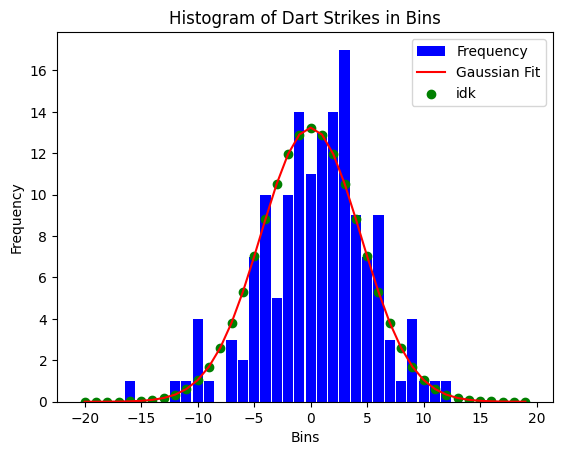

In [104]:
#Lab1 - Dartboard Statistics: Histogram

from matplotlib import pyplot as plt 
from scipy import stats
from scipy.optimize import curve_fit 
import numpy as np  
import csv

def load_data(filename):
    mylist = []
    with open(filename) as numbers:
        numbers_data = csv.reader(numbers, delimiter=",")
        next(numbers_data) #skip the header
        for row in numbers_data:
            mylist.append(row)
        return mylist

def strike_data(datalist):
    strike_column = []
    for i in range(len(datalist)):
        row = datalist[i]
        strike_column.append(int(datalist[i][1]))
    return strike_column

# Define the Gaussian function 
def Gauss(x, A, B): 
    y = A*np.exp(-1*B*x**2) 
    return y
    
a = load_data("Ogedengbe_Peter_dartboard.csv")
strikes = np.array(strike_data(a))
plt.figure()
note1 = plt.hist(strikes, bins=np.arange(-20, 21, 1).tolist(), label='Frequency', align='left', histtype='bar', rwidth=0.9, color='blue') 

xdata = np.asarray(bins[0:40]) 
ydata1 = np.asarray(note1[0]) 
print(ydata1)

parameters, covariance = curve_fit(Gauss, xdata, ydata) 
fit_A = parameters[0] 
fit_B = parameters[1] 
fit_y1 = Gauss(xdata, fit_A, fit_B)

plt.plot(xdata, fit_y, '-', label='Gaussian Fit', color="red")
y_data1 = plt.scatter(xdata, fit_y1, marker='o', label='idk', color="green") 
plt.title("Histogram of Dart Strikes in Bins") 
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Sample Mean & Standard Deviation

In [105]:
#Lab1 (Part 1) - Dartboard Statistics: Sample Mean, Standard Deviation and Standard Error
def avg(data):
    sum = 0; length = 0
    for value in data:
        sum += value; length += 1
    return sum/length

def standard_dev(data):
    sum = 0; length = 0
    mean = avg(data)
    for value in data:
        param_1 = (value-mean)**2; sum += param_1; length += 1
    return (sum/length)**0.5

def error(std, n):
    value = std / (n ** 0.5)
    return value

mean_py = np.mean(strikes); std_py = np.std(strikes); err_py = stats.sem(strikes)
print("Python built-in functions (numpy and scipy):")
print(f"Sample mean: {round(mean_py, 4)}")
print(f"Standard deviation: {round(std_py, 4)}")
print(f"Standard error: {round(err_py, 4)}\n")

mean_hand = avg(strikes); std_hand = standard_dev(strikes); err_hand = error(std_hand, len(strikes))
print("Hand built functions (numpy and scipy):")
print(f"Sample mean: {round(mean_hand, 4)}")
print(f"Standard deviation: {round(std_hand, 4)}")
print(f"Standard error: {round(err_hand, 5)}\n")

Python built-in functions (numpy and scipy):
Sample mean: 0.4667
Standard deviation: 4.7521
Standard error: 0.3893

Hand built functions (numpy and scipy):
Sample mean: 0.4667
Standard deviation: 4.7521
Standard error: 0.38801



## Part 2

In [106]:
#Lab1 (Part 2)- Dartboard Statistics: Sample Mean, Standard Deviation and Standard Error

class_data = load_data("PHYS295_ClassData.csv")
class_strikes = strike_data(class_data)

mean_py = np.mean(class_strikes); std_py = np.std(class_strikes); err_py = stats.sem(class_strikes)
print("Python built-in functions (numpy and scipy):")
print(f"Sample mean: {round(mean_py, 4)}")
print(f"Standard deviation: {round(std_py, 4)}")
print(f"Standard error: {round(err_py, 4)}\n")

mean_hand = avg(class_strikes); std_hand = standard_dev(class_strikes); err_hand = error(std_hand, len(class_strikes))
print("Hand built functions (numpy and scipy):")
print(f"Sample mean: {round(mean_hand, 4)}")
print(f"Standard deviation: {round(std_hand, 4)}")
print(f"Standard error: {round(err_hand, 4)}\n")

Python built-in functions (numpy and scipy):
Sample mean: 0.4798
Standard deviation: 6.6005
Standard error: 0.0678

Hand built functions (numpy and scipy):
Sample mean: 0.4798
Standard deviation: 6.6005
Standard error: 0.0678



[  2.86552494   4.82840548   7.92105059  12.65148051  19.67340013
  29.78495921  43.90299065  63.00437552  88.0292148  119.74639715
 158.59065529 204.49007883 256.71213685 313.76180289 373.36469796
 432.55958899 487.90823239 535.80882043 572.87659841 596.33708216
 604.3688341  596.33708216 572.87659841 535.80882043 487.90823239
 432.55958899 373.36469796 313.76180289 256.71213685 204.49007883
 158.59065529 119.74639715  88.0292148   63.00437552  43.90299065
  29.78495921  19.67340013  12.65148051   7.92105059   4.82840548]


C:\Users\Taiwo Ogedengbe\AppData\Local\Temp\ipykernel_38688\1124335327.py:27: RuntimeWarning: overflow encountered in exp
  y = A*np.exp(-1*B*x**2)


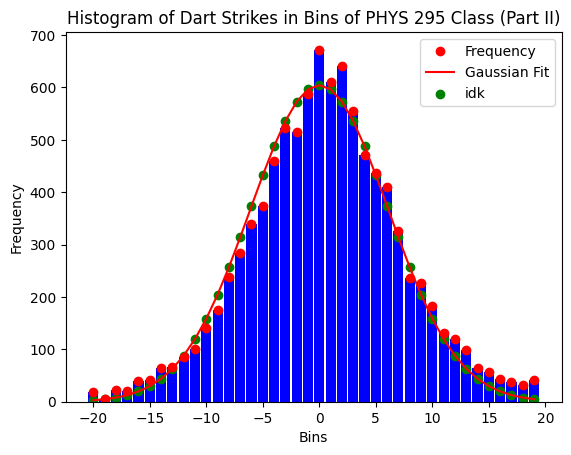

In [111]:
plt.figure()
bins = np.arange(-20, 21, 1).tolist()
note2 = plt.hist(class_strikes, bins, align='left', histtype='bar', rwidth=0.9, color='blue') 
xdata = np.asarray(bins[0:40]) 
ydata2 = np.asarray(note2[0]) 

parameters, covariance = curve_fit(Gauss, xdata, ydata2) 
fit_A = parameters[0] 
fit_B = parameters[1] 
fit_y2 = Gauss(xdata, fit_A, fit_B)
print(fit_y2)
plt.plot(xdata, ydata2, 'o', label='Frequency', color='red') 
plt.plot(xdata, fit_y2, '-', label='Gaussian Fit', color="red")
y_data = plt.scatter(xdata, fit_y2, marker='o', label='idk', color="green") 
plt.title("Histogram of Dart Strikes in Bins of PHYS 295 Class (Part II)") 
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Chi Square Test

In [123]:
data1 = [ydata1, fit_y1]
stat, p, dof, expected = stats.chi2_contingency(data1)

# interpret p-value
alpha = 0.01
print(stat)
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

15.392677698029807
p value is 0.9997458092674447
Independent (H0 holds true)


In [124]:
data2 = [ydata2, fit_y2]
stat, p, dof, expected = stats.chi2_contingency(data2)

# interpret p-value
alpha = 0.01
print(stat)
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

149.69488531913697
p value is 6.9899013525322325e-15
Dependent (reject H0)
